# IOCL RO Safety — NUMERICAL Analysis Pipeline (LOCAL / VS Code)
The numerical half of the project. Runs on the Yes/No/NA boxes — **no ML, pure formula**,
because the relationship is known: `compliance = Yes / (Yes + No) × 100`.

Two parts:
- **Part A — the scoring pipeline** (reusable logic your PWA backend will call).
- **Part B — network analysis** (charts for your report).

Setup once: `pip install pandas numpy matplotlib seaborn`

## STEP 0 — Imports

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_style('whitegrid')
print('Ready.')

Ready.


## STEP 1 — Load data
`Inspection_Dataset` = one row per checklist item (raw). `Summary` = one row per inspection (pre-computed, used to validate).

In [2]:
ITEMS_PATH   = 'IOCL_Inspection_Dataset.csv'   # change paths if needed
SUMMARY_PATH = 'IOCL_Inspection_Summary.csv'

items   = pd.read_csv(ITEMS_PATH)
summary = pd.read_csv(SUMMARY_PATH)
print('Item rows:', len(items), '| Inspections:', len(summary))
print('Sections:', sorted(items['section'].dropna().unique()))

Item rows: 102528 | Inspections: 712
Sections: ['Abrasive_Blasting_Painting', 'Concreting', 'Confined_Space', 'Cutting_Welding_Grinding', 'Demolishing', 'Documentation', 'Electrical_Safety', 'Emergency_Procedures', 'Excavation', 'Formwork_Reinforcement', 'General', 'Housekeeping', 'Hydrocarbon_Safety', 'Material_Handling_Lifting', 'PPE', 'Permits', 'Radiography', 'Road_Work', 'Safety_Awareness_Training', 'Welfare_Facilities', 'Working_at_Heights']


## PART A — THE SCORING PIPELINE

### STEP 2 — Compliance from raw responses
NA is excluded (item not applicable). This is the whole 'model' — a formula.

In [3]:
def compliance(df):
    yes = (df['response'] == 'Yes').sum()
    no  = (df['response'] == 'No').sum()
    return round(100 * yes / (yes + no), 2) if (yes + no) else 0.0

# section-wise (skip sections that are entirely NA = not applicable to this station)
def section_scores(df):
    out = {}
    for sec, g in df.groupby('section'):
        yes = (g['response'] == 'Yes').sum(); no = (g['response'] == 'No').sum()
        if yes + no > 0:
            out[sec] = round(100 * yes / (yes + no), 2)
    return out

### STEP 3 — Numerical risk from compliance (tunable thresholds, NO ML)

In [4]:
HIGH_BELOW   = 70    # compliance < 70  -> High numerical risk
MEDIUM_BELOW = 85    # 70-85           -> Medium ; >=85 -> Low

def numerical_risk(comp):
    if comp < HIGH_BELOW:   return 'High'
    if comp < MEDIUM_BELOW: return 'Medium'
    return 'Low'

def risk_score(comp):
    # 0 = perfectly safe, 100 = worst. Simple + interpretable.
    return round(100 - comp, 1)

### STEP 4 — Hidden-risk detection (the project's signature feature)
Item ticked **Yes** but its remark is labelled **High** risk = looks compliant, actually dangerous.

In [5]:
def hidden_risks(df):
    mask = (df['response'] == 'Yes') & (df['risk_level'] == 'High')
    return int(mask.sum())

### STEP 5 — One full inspection result, and validate against the Summary file

In [6]:
def analyse_inspection(df):
    comp = compliance(df)
    return {
        'inspection_id': df['inspection_id'].iloc[0],
        'ro_name': df['ro_name'].iloc[0],
        'compliance_score': comp,
        'numerical_risk_level': numerical_risk(comp),
        'numerical_risk_score': risk_score(comp),
        'section_scores': section_scores(df),
        'hidden_risks': hidden_risks(df),
        'weak_sections': [s for s, v in section_scores(df).items() if v < MEDIUM_BELOW],
    }

one = items[items['inspection_id'] == 'INSP00001']
res = analyse_inspection(one)
import json; print(json.dumps(res, indent=2))
print('\nSummary file says compliance =',
      summary.loc[summary.inspection_id=='INSP00001','compliance_score'].iloc[0])

{
  "inspection_id": "INSP00001",
  "ro_name": "IOCL RO Delhi Cantonment",
  "compliance_score": 75.93,
  "numerical_risk_level": "Medium",
  "numerical_risk_score": 24.1,
  "section_scores": {
    "Abrasive_Blasting_Painting": 50.0,
    "Concreting": 0.0,
    "Confined_Space": 80.0,
    "Cutting_Welding_Grinding": 50.0,
    "Documentation": 100.0,
    "Electrical_Safety": 70.0,
    "Emergency_Procedures": 90.91,
    "Excavation": 50.0,
    "General": 81.82,
    "Housekeeping": 71.43,
    "Hydrocarbon_Safety": 90.0,
    "PPE": 84.62,
    "Permits": 80.0,
    "Road_Work": 100.0,
    "Safety_Awareness_Training": 50.0,
    "Welfare_Facilities": 66.67,
    "Working_at_Heights": 100.0
  },
  "hidden_risks": 1,
  "weak_sections": [
    "Abrasive_Blasting_Painting",
    "Concreting",
    "Confined_Space",
    "Cutting_Welding_Grinding",
    "Electrical_Safety",
    "Excavation",
    "General",
    "Housekeeping",
    "PPE",
    "Permits",
    "Safety_Awareness_Training",
    "Welfare_Faciliti

In [7]:
# Validate our formula across ALL inspections matches the precomputed Summary
recalc = items.groupby('inspection_id').apply(compliance).rename('ours')
chk = summary.set_index('inspection_id')['compliance_score'].to_frame('summary').join(recalc)
chk['diff'] = (chk['ours'] - chk['summary']).abs()
print('Inspections checked:', len(chk), '| max difference:', round(chk['diff'].max(), 3))
print('=> our pipeline reproduces the official compliance score.' if chk['diff'].max() < 0.1 else 'MISMATCH - investigate')

Inspections checked: 712 | max difference: 0.0
=> our pipeline reproduces the official compliance score.


C:\Users\Shrish Singh Sourya\AppData\Local\Temp\ipykernel_25144\2058239643.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  recalc = items.groupby('inspection_id').apply(compliance).rename('ours')


## PART B — NETWORK ANALYSIS (for your report)
These run on the 712-inspection Summary file.

### Compliance distribution + by RO profile

C:\Users\Shrish Singh Sourya\AppData\Local\Temp\ipykernel_25144\707387909.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=summary, x='ro_profile', y='compliance_score', order=prof, ax=ax[1], palette='RdYlGn_r')


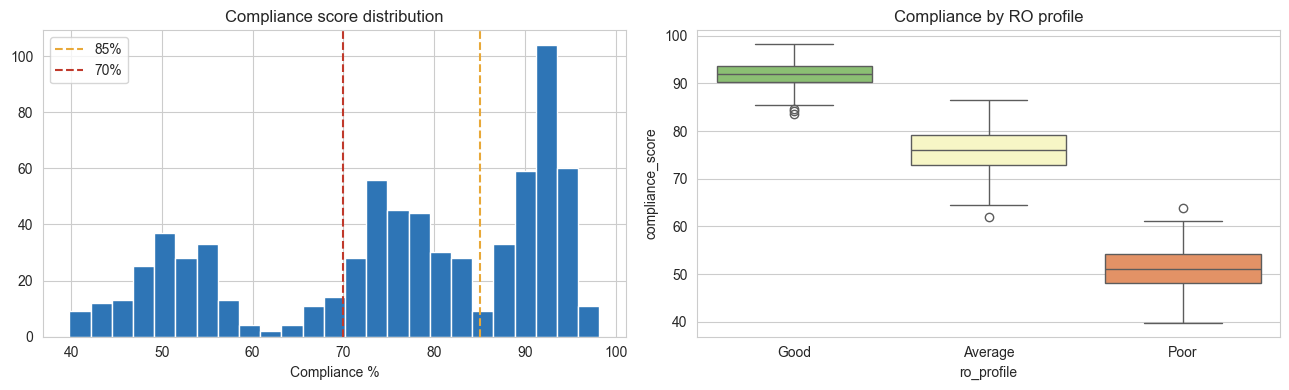

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].hist(summary['compliance_score'], bins=25, color='#2E75B6', edgecolor='white')
ax[0].axvline(MEDIUM_BELOW, color='#E8A838', ls='--', label=f'{MEDIUM_BELOW}%')
ax[0].axvline(HIGH_BELOW, color='#C0392B', ls='--', label=f'{HIGH_BELOW}%')
ax[0].set_title('Compliance score distribution'); ax[0].set_xlabel('Compliance %'); ax[0].legend()

order = ['Good','Average','Poor']
prof = [p for p in order if p in summary['ro_profile'].unique()]
sns.boxplot(data=summary, x='ro_profile', y='compliance_score', order=prof, ax=ax[1], palette='RdYlGn_r')
ax[1].set_title('Compliance by RO profile'); plt.tight_layout(); plt.show()

### Section-wise weakness heatmap (which areas fail most across the network)

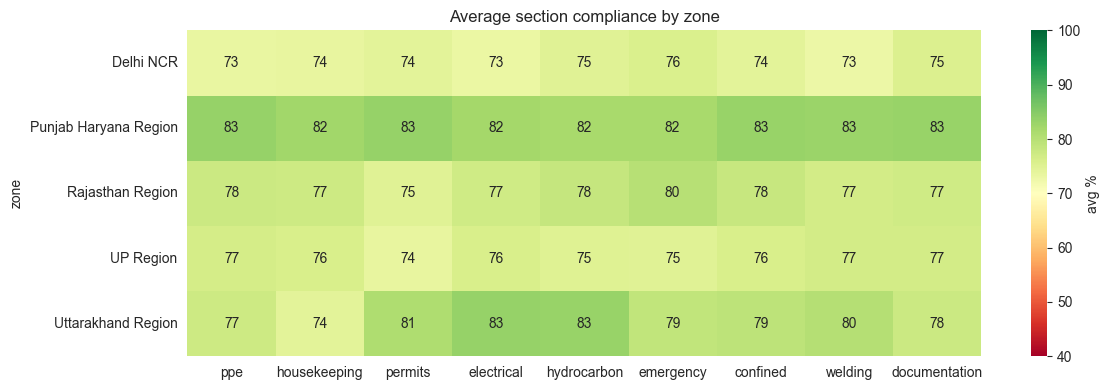

In [9]:
SECTION_COLS = ['section_ppe_score','section_housekeeping_score','section_permits_score',
    'section_electrical_score','section_hydrocarbon_score','section_emergency_score',
    'section_confined_score','section_welding_score','section_documentation_score']
mean_by_zone = summary.groupby('zone')[SECTION_COLS].mean()
mean_by_zone.columns = [c.replace('section_','').replace('_score','') for c in mean_by_zone.columns]
plt.figure(figsize=(12,4))
sns.heatmap(mean_by_zone, annot=True, fmt='.0f', cmap='RdYlGn', vmin=40, vmax=100, cbar_kws={'label':'avg %'})
plt.title('Average section compliance by zone'); plt.tight_layout(); plt.show()

### Compliance trend over time

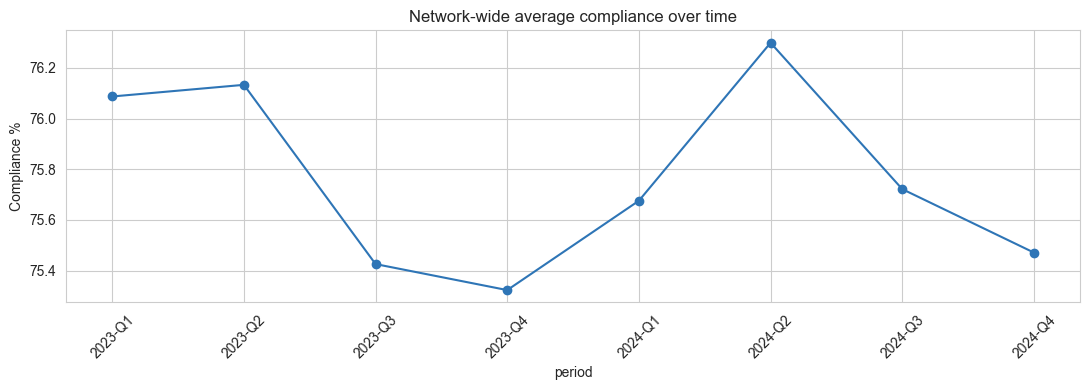

In [10]:
summary['period'] = summary['year'].astype(str) + '-' + summary['quarter'].astype(str)
trend = summary.groupby('period')['compliance_score'].mean()
plt.figure(figsize=(11,4))
trend.plot(marker='o', color='#2E75B6')
plt.title('Network-wide average compliance over time'); plt.ylabel('Compliance %')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

### The hidden-risk scatter — the most important chart
Top-right = **danger zone**: high compliance (boxes look fine) BUT high semantic risk (remarks reveal problems).
Note how few points sit there — in this synthetic data the two signals agree (corr ≈ −0.98), so the combined
engine matters most exactly on these rare divergent cases.

Correlation (compliance vs semantic risk): -0.981


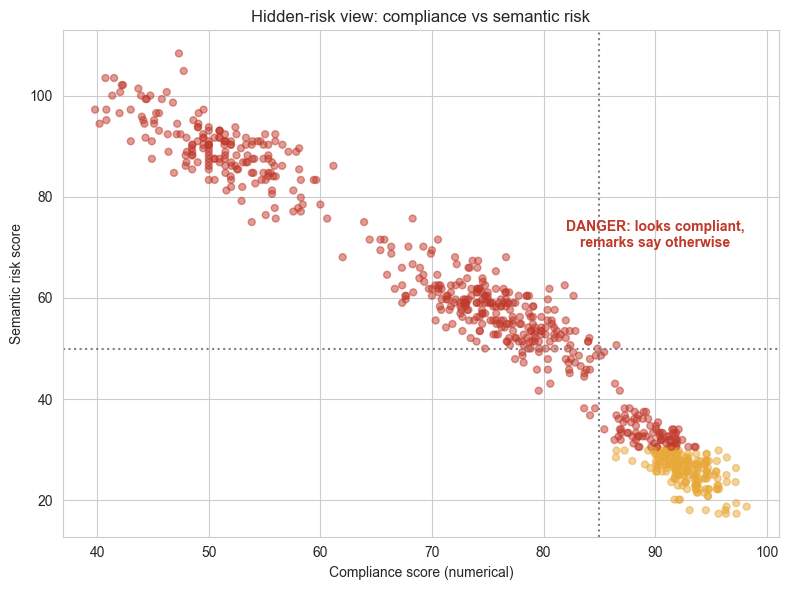

In [11]:
plt.figure(figsize=(8,6))
colors = summary['overall_risk_level'].map({'High':'#C0392B','Medium':'#E8A838','Low':'#5BA85B'})
plt.scatter(summary['compliance_score'], summary['semantic_risk_score'], c=colors, alpha=0.5, s=25)
plt.axvline(MEDIUM_BELOW, color='gray', ls=':'); plt.axhline(50, color='gray', ls=':')
plt.xlabel('Compliance score (numerical)'); plt.ylabel('Semantic risk score')
plt.title('Hidden-risk view: compliance vs semantic risk')
plt.annotate('DANGER: looks compliant,\nremarks say otherwise', xy=(90, 70),
             color='#C0392B', fontweight='bold', ha='center')
print('Correlation (compliance vs semantic risk):',
      round(summary['compliance_score'].corr(summary['semantic_risk_score']), 3))
plt.tight_layout(); plt.show()

## STEP 6 — What this produces for the Combined Risk Engine
`analyse_inspection()` returns the numerical object (compliance, section scores, numerical risk,
hidden-risk count). Next step: the Combined Engine blends `numerical_risk_score` (40%) with the
semantic score from your BERT+LogReg bundle (60%) into the Final Risk Index.

In [12]:
# Example: numerical inputs ready for blending, for the first 5 inspections
for iid in summary['inspection_id'].head(5):
    df = items[items['inspection_id'] == iid]
    r = analyse_inspection(df)
    print(f"{iid}  comp={r['compliance_score']:5.1f}  numRisk={r['numerical_risk_level']:6s}  "
          f"score={r['numerical_risk_score']:5.1f}  hidden={r['hidden_risks']}")

INSP00001  comp= 75.9  numRisk=Medium  score= 24.1  hidden=1
INSP00002  comp= 71.3  numRisk=Medium  score= 28.7  hidden=3
INSP00003  comp= 73.5  numRisk=Medium  score= 26.5  hidden=1
INSP00004  comp= 83.3  numRisk=Medium  score= 16.7  hidden=2
INSP00005  comp= 75.5  numRisk=Medium  score= 24.5  hidden=1
